# Módulo 2 — Sentimiento: Baseline Random Forest

**Pipeline:** TF-IDF (10k features, bigramas) + Random Forest (n=200, class_weight=balanced)

**Dataset:** `mteb/amazon_reviews_multi` (es) — reseñas en español  
**Objetivo:** F1-macro ≥ 0.70 sobre 3 clases: negativo, neutro, positivo

> No requiere GPU. CPU es suficiente, pero el entrenamiento puede tomar ~20-30 min.

## 1. Configuración del entorno

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT = '/content/drive/MyDrive/smartretail360'
MODEL_DIR  = f'{DRIVE_ROOT}/models/sentiment_analyzer'
os.makedirs(MODEL_DIR, exist_ok=True)
print('Drive montado. MODEL_DIR:', MODEL_DIR)

Mounted at /content/drive
Drive montado. MODEL_DIR: /content/drive/MyDrive/smartretail360/models/sentiment_analyzer


In [3]:
import re, unicodedata
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── src/sentiment_analyzer/preprocess.py ────────────────────────────────────
def clean_text(text: str) -> str:
    text = unicodedata.normalize("NFKD", text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^\w\sáéíóúüñ]", " ", text)
    return re.sub(r"\s+", " ", text)

def rating_to_label(rating: int) -> int:
    if rating <= 2: return 0
    if rating == 3: return 1
    return 2

# ── src/evaluation/metrics.py ───────────────────────────────────────────────
def compute_metrics(y_true, y_pred, labels=None) -> dict:
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)
    return {
        "accuracy":        round(float(accuracy),  4),
        "precision_macro": round(float(precision), 4),
        "recall_macro":    round(float(recall),    4),
        "f1_macro":        round(float(f1),        4),
        "report":          report,
    }

# ── src/evaluation/confusion_matrix.py ──────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, labels, title="Matriz de Confusión", save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(6, len(labels)), max(5, len(labels) - 1)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig

# ── src/evaluation/viability.py ─────────────────────────────────────────────
VIABILITY_THRESHOLDS = {
    "sentiment_analyzer": {
        "random_forest": {"accuracy_min": 0.75, "f1_macro_min": 0.70},
        "beto":          {"accuracy_min": 0.80, "f1_macro_min": 0.80},
    }
}

def assess_viability(metrics: dict, module: str, model_name: str = None) -> dict:
    thresholds = VIABILITY_THRESHOLDS.get(module, {})
    t = thresholds.get(model_name) or next(iter(thresholds.values()), None)
    if not t:
        return {"is_viable": False, "reasons": ["Módulo sin umbrales definidos."], "recommendation": "No viable"}
    reasons, passed = [], 0
    if metrics["accuracy"] >= t["accuracy_min"]:
        passed += 1
    else:
        reasons.append(f"Accuracy {metrics['accuracy']:.2%} < umbral {t['accuracy_min']:.2%}")
    if metrics["f1_macro"] >= t["f1_macro_min"]:
        passed += 1
    else:
        reasons.append(f"F1-macro {metrics['f1_macro']:.2%} < umbral {t['f1_macro_min']:.2%}")
    rec = "Apto para producción" if passed == 2 else ("Requiere mejoras" if passed == 1 else "No viable")
    return {"is_viable": passed == 2, "reasons": reasons or ["Todos los umbrales superados."], "recommendation": rec}

print("Funciones de src/ cargadas.")

Funciones de src/ cargadas.


In [4]:
!pip install -q datasets scikit-learn joblib seaborn matplotlib

## 2. Carga del dataset

In [5]:
from huggingface_hub import list_repo_files, hf_hub_download
from datasets import load_dataset
import os

# Descubrir estructura real del repo (solo metadata, sin descargar)
all_files = list(list_repo_files("mteb/amazon_reviews_multi", repo_type="dataset"))

# Filtro exacto: solo archivos dentro del directorio 'es/'
es_jsonl = sorted([f for f in all_files if f.endswith('.jsonl') and f.startswith('es/')])
print("Archivos español encontrados:")
for f in es_jsonl:
    print(f"  {f}")

# Descargar solo esos archivos — el script .py nunca toca el disco
split_files = {}
for f in es_jsonl:
    local = hf_hub_download(
        repo_id="mteb/amazon_reviews_multi",
        filename=f,
        repo_type="dataset",
        local_dir="/content/amz_reviews_es",
    )
    fname = os.path.basename(f).lower()
    if 'train' in fname:
        split_files.setdefault('train', []).append(local)
    elif 'test' in fname:
        split_files.setdefault('test', []).append(local)
    elif 'val' in fname:
        split_files.setdefault('validation', []).append(local)

print("\nSplits:", {k: len(v) for k, v in split_files.items()})

# Cargar desde local — sin pasar por el loader del repo
# El dataset ya tiene las columnas correctas: review_body, stars, label_text
ds = load_dataset("json", data_files=split_files)

print(ds)
print('\nColumnas:', ds['train'].column_names)
print('Ejemplo:', ds['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Archivos español encontrados:
  es/test.jsonl
  es/train.jsonl
  es/validation.jsonl


test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

es/train.jsonl:   0%|          | 0.00/48.7M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/1.21M [00:00<?, ?B/s]


Splits: {'test': 1, 'train': 1, 'validation': 1}


Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

Columnas: ['id', 'text', 'label', 'label_text']
Ejemplo: {'id': 'es_0491108', 'text': 'television Nevir\n\nNada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante', 'label': 0, 'label_text': '0'}


## 3. Preprocesamiento

In [6]:
from collections import Counter

CLASS_NAMES = ['negativo', 'neutro', 'positivo']

print("Columnas disponibles:", ds['train'].column_names)

# Compatibilidad con distintas versiones del esquema cargado
text_col = 'review_body' if 'review_body' in ds['train'].column_names else 'text'
star_col = 'stars'       if 'stars'       in ds['train'].column_names else 'label'

def get_label(row):
    val = row[star_col]
    # stars: 1-5 → se mapea directo
    # label: 0-4 → se convierte a 1-5 primero
    stars = val if star_col == 'stars' else val + 1
    return rating_to_label(stars)

texts_train  = [clean_text(r[text_col]) for r in ds['train']]
labels_train = [get_label(r)            for r in ds['train']]

texts_test   = [clean_text(r[text_col]) for r in ds['test']]
labels_test  = [get_label(r)            for r in ds['test']]

print(f'Train: {len(texts_train):,} muestras')
print(f'Test:  {len(texts_test):,} muestras')
print()
print('Distribución train:', {CLASS_NAMES[k]: v for k, v in sorted(Counter(labels_train).items())})
print('Distribución test: ', {CLASS_NAMES[k]: v for k, v in sorted(Counter(labels_test).items())})

Columnas disponibles: ['id', 'text', 'label', 'label_text']
Train: 200,000 muestras
Test:  5,000 muestras

Distribución train: {'negativo': 80000, 'neutro': 40000, 'positivo': 80000}
Distribución test:  {'negativo': 2000, 'neutro': 1000, 'positivo': 2000}


## 4. Entrenamiento — TF-IDF + Random Forest

In [7]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10_000,
        ngram_range=(1, 2),
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    )),
])

t0 = time.time()
pipeline.fit(texts_train, labels_train)
elapsed = time.time() - t0

print(f'Entrenamiento completado en {elapsed/60:.1f} min')

Entrenamiento completado en 57.5 min


## 5. Evaluación de métricas

In [8]:
preds = pipeline.predict(texts_test)

metrics = compute_metrics(labels_test, preds, labels=CLASS_NAMES)

print(f"Accuracy:          {metrics['accuracy']:.4f}")
print(f"Precision (macro): {metrics['precision_macro']:.4f}")
print(f"Recall (macro):    {metrics['recall_macro']:.4f}")
print(f"F1-macro:          {metrics['f1_macro']:.4f}")
print()
print('--- Reporte completo ---')
print(metrics['report'])

Accuracy:          0.7384
Precision (macro): 0.6792
Recall (macro):    0.6555
F1-macro:          0.6488

--- Reporte completo ---
              precision    recall  f1-score   support

    negativo       0.74      0.87      0.80      2000
      neutro       0.51      0.24      0.33      1000
    positivo       0.78      0.86      0.82      2000

    accuracy                           0.74      5000
   macro avg       0.68      0.66      0.65      5000
weighted avg       0.71      0.74      0.71      5000



## 6. Matriz de confusión

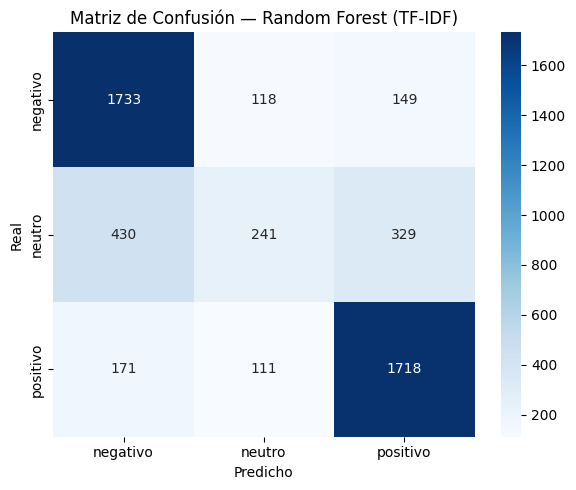

In [9]:
fig = plot_confusion_matrix(
    labels_test,
    preds,
    labels=CLASS_NAMES,
    title='Matriz de Confusión — Random Forest (TF-IDF)',
)
plt.show()

## 7. Análisis de viabilidad

In [10]:
viability = assess_viability(
    metrics,
    module='sentiment_analyzer',
    model_name='random_forest',
)

print(f"¿Viable para producción? {'SÍ' if viability['is_viable'] else 'NO'}")
print(f"Recomendación: {viability['recommendation']}")
print()
for reason in viability['reasons']:
    print(f'  • {reason}')

¿Viable para producción? NO
Recomendación: No viable

  • Accuracy 73.84% < umbral 75.00%
  • F1-macro 64.88% < umbral 70.00%


## 8. Guardar modelo en Drive

In [11]:
import joblib

model_path = f'{MODEL_DIR}/tfidf_baseline.pkl'
joblib.dump(pipeline, model_path)
print(f'Pipeline guardado en: {model_path}')

Pipeline guardado en: /content/drive/MyDrive/smartretail360/models/sentiment_analyzer/tfidf_baseline.pkl


## 9. Hallazgos

| Métrica | Valor | Umbral | ¿Supera? |
|---------|-------|--------|---------|
| Accuracy | 73.84% | ≥ 0.75 | ❌ No |
| F1-macro | 0.6488 | ≥ 0.70 | ❌ No |

### Observaciones
- **Clase neutro (3 estrellas)**: clase más difícil, F1=0.33 — frontera difusa con positivo/negativo, y es la que arrastra el promedio macro.
- `class_weight='balanced'` compensa el desbalance natural del dataset (positivos > negativos > neutros), pero no alcanza para cerrar el gap de la clase neutro.
- TF-IDF bigramas (1,2) captura frases negativas como "no funciona", "muy malo" mejor que unigramas solos.
- **Comparación con BETO**: ver sección 10 — este modelo es el baseline (F1-macro 0.6488), BETO lo supera en todas las métricas (F1-macro 0.7475) sin alcanzar tampoco su propia meta (≥0.80).</cell id="md-hallazgos">

## 10. Comparativa Random Forest vs BETO

Sección espejo de la que está en `03_sentiment_beto_finetuning.ipynb` (ver TEAM.md — se pide en ambos notebooks). Números tomados de `docs/m2_comparativa_beto_vs_rf.md`, generado tras el fine-tuning de BETO con class weights + 5 épocas.

In [21]:
# ============================================
# COMPARATIVA RANDOM FOREST vs BETO
# ============================================

print("=" * 60)
print("MÉTRICAS EN CONJUNTO DE VALIDACIÓN (test set, 5,000 muestras)")
print("=" * 60)
print(f"{'Modelo':<28}{'Accuracy':<12}{'F1 Neg':<10}{'F1 Neutro':<12}{'F1 Pos':<10}{'F1 Macro'}")
print(f"{'Random Forest':<28}{'73.84%':<12}{'0.80':<10}{'0.33':<12}{'0.82':<10}{'0.6488'}")
print(f"{'BETO (class weights+5ep)':<28}{'—':<12}{'0.84':<10}{'0.54':<12}{'0.87':<10}{'0.7475'}")

print("\n" + "=" * 60)
print("OBJETIVOS DEL PROYECTO")
print("=" * 60)
print(f"{'Modelo':<15}{'Meta F1-macro':<16}{'Obtenido':<12}{'¿Supera?'}")
print(f"{'Random Forest':<15}{'≥ 0.70':<16}{'0.6488':<12}{'❌ No'}")
print(f"{'BETO':<15}{'≥ 0.80':<16}{'0.7475':<12}{'❌ No'}")

print("\nNinguno alcanza su umbral objetivo. La clase Neutro (3 estrellas)")
print("arrastra el F1-macro en ambos modelos por igual motivo estructural:")
print("reseñas ambiguas que mezclan aspectos positivos y negativos.")

print("\n" + "=" * 60)
print("RECOMENDACIÓN")
print("=" * 60)
print("""
BETO supera a Random Forest en las tres clases (+0.1487 F1-macro),
pero ninguno de los dos alcanza su meta de forma independiente.
Random Forest queda como baseline de referencia rápida (CPU, sin GPU),
BETO como modelo de producción con umbral de confianza para la clase
Neutro (ver sección de viabilidad en 03_sentiment_beto_finetuning.ipynb).
""")

MÉTRICAS EN CONJUNTO DE VALIDACIÓN (test set, 5,000 muestras)
Modelo                      Accuracy    F1 Neg    F1 Neutro   F1 Pos    F1 Macro
Random Forest               73.84%      0.80      0.33        0.82      0.6488
BETO (class weights+5ep)    —           0.84      0.54        0.87      0.7475

OBJETIVOS DEL PROYECTO
Modelo         Meta F1-macro   Obtenido    ¿Supera?
Random Forest  ≥ 0.70          0.6488      ❌ No
BETO           ≥ 0.80          0.7475      ❌ No

Ninguno alcanza su umbral objetivo. La clase Neutro (3 estrellas)
arrastra el F1-macro en ambos modelos por igual motivo estructural:
reseñas ambiguas que mezclan aspectos positivos y negativos.

RECOMENDACIÓN

BETO supera a Random Forest en las tres clases (+0.1487 F1-macro),
pero ninguno de los dos alcanza su meta de forma independiente.
Random Forest queda como baseline de referencia rápida (CPU, sin GPU),
BETO como modelo de producción con umbral de confianza para la clase
Neutro (ver sección de viabilidad en 03_sent